In [ ]:
!pip install --upgrade "transformers[torch]" datasets evaluate nltk rouge_score
!pip install --upgrade accelerate peft

import transformers
import accelerate
import datasets
import evaluate
import nltk
import torch
print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("Datasets:", datasets.__version__)
print("Evaluate:", evaluate.__version__)
print("PyTorch version:", torch.__version__)

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
from datasets import load_dataset
import evaluate
from transformers import (
    BartTokenizer,
    BartForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
from peft import LoraConfig, get_peft_model, TaskType

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.5 MB/s eta 0:00:00


In [ ]:
import transformers
import accelerate
import datasets
import evaluate
import nltk
import torch
print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("Datasets:", datasets.__version__)
print("Evaluate:", evaluate.__version__)
print("PyTorch version:", torch.__version__)

Transformers: 4.49.0
Accelerate: 1.5.1
Datasets: 3.3.2
Evaluate: 0.4.3
PyTorch version: 2.5.1+cu124


In [ ]:
###############################################################################
# 1. DATA LOADING
###############################################################################
dataset_path = "/content/drive/MyDrive/News_Category_Dataset_v3.json"

dataset = load_dataset("json", data_files={"train": dataset_path}, field=None)

if "short_description" in dataset["train"].column_names and "description" not in dataset["train"].column_names:
    dataset["train"] = dataset["train"].rename_column("short_description", "description")

assert "description" in dataset["train"].column_names, "Missing 'description' column."
assert "headline" in dataset["train"].column_names, "Missing 'headline' column."

dataset = dataset["train"].train_test_split(test_size=0.1)
print("Columns:", dataset["train"].column_names)
print(f"Train size: {len(dataset['train'])}, Test size: {len(dataset['test'])}")

Generating train split: 0 examples [00:00, ? examples/s]

Columns: ['link', 'headline', 'category', 'description', 'authors', 'date']
Train size: 188574, Test size: 20953


In [ ]:
###############################################################################
# 2. MODEL & TOKENIZER SETUP
###############################################################################
model_name = "facebook/bart-base"
tokenizer = BartTokenizer.from_pretrained(model_name)
base_model = BartForConditionalGeneration.from_pretrained(model_name)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"]
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

trainable params: 442,368 || all params: 139,862,784 || trainable%: 0.3163


In [ ]:
###############################################################################
# 3. PREPROCESSING
###############################################################################
max_input_length = 250
max_target_length = 30

def preprocess_function(examples):
    inputs = [desc if desc is not None and desc.strip() != "" else "Empty description"
              for desc in examples["description"]]
    targets = [headline if headline is not None and headline.strip() != "" else "Empty headline"
               for headline in examples["headline"]]

    model_inputs = tokenizer(inputs, max_length=max_input_length, truncation=True)
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(targets, max_length=max_target_length, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_datasets = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=dataset["train"].column_names
)

train_dataset = tokenized_datasets["train"]
eval_dataset = tokenized_datasets["test"]


Map:   0%|          | 0/188574 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3970: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/20953 [00:00<?, ? examples/s]

In [ ]:
###############################################################################
# 4. DATA COLLATOR & METRIC
###############################################################################
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)
bleu = evaluate.load("bleu")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    decoded_preds = []
    for pred_ids in predictions:
        try:
            text = tokenizer.decode(pred_ids, skip_special_tokens=True)
            decoded_preds.append(text)
        except:
            decoded_preds.append("")

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = []
    for label_ids in labels:
        try:
            text = tokenizer.decode(label_ids, skip_special_tokens=True)
            decoded_labels.append(text)
        except:
            decoded_labels.append("")

    result = bleu.compute(
        predictions=decoded_preds,
        references=[[ref] for ref in decoded_labels]
    )
    return {"bleu": result["bleu"] * 100}

In [ ]:
###############################################################################
# 5. TRAINING ARGUMENTS (Adjusted for A100)
###############################################################################
training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/checkpoints",
    evaluation_strategy="epoch",
    per_device_train_batch_size=16,   # Increased batch size on A100
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=1,      # No need for accumulation if batch size is high enough
    learning_rate=2e-5,
    num_train_epochs=10,  # You can adjust based on dataset size
    weight_decay=0.01,
    save_strategy="epoch",
    logging_steps=100,
    predict_with_generate=True,
    fp16=True,          # Mixed precision for speed and memory efficiency
    report_to=[],
    label_smoothing_factor=0.1
)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
###############################################################################
# 6. TRAINER
###############################################################################
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

<ipython-input-10-49492315a26c>:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
No label_names provided for model class `PeftModelForSeq2SeqLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [ ]:
###############################################################################
# 7. TRAIN & EVALUATE
###############################################################################
trainer.train()
eval_results = trainer.evaluate()
print("Evaluation results:", eval_results)

Epoch,Training Loss,Validation Loss,Bleu
1,5.158800,4.755455,0.028571
2,5.123000,4.708498,0.386869
3,5.079900,4.689265,0.444710
4,5.087500,4.683679,0.501519
5,5.076200,4.679652,0.504150


Evaluation results: {'eval_loss': 4.679651737213135, 'eval_bleu': 0.5041497299075453, 'eval_runtime': 686.9066, 'eval_samples_per_second': 30.503, 'eval_steps_per_second': 1.907, 'epoch': 5.0}


In [ ]:
###############################################################################
# 8. PREDICT ON THE ENTIRE EVAL DATASET
###############################################################################
pred_obj = trainer.predict(eval_dataset)
predictions = pred_obj.predictions
label_ids = pred_obj.label_ids

def safe_decode(token_ids):
    token_ids = [token if token != -100 else tokenizer.pad_token_id for token in token_ids]
    return tokenizer.decode(token_ids, skip_special_tokens=True)

decoded_preds = [safe_decode(pred) for pred in predictions]
decoded_labels = [safe_decode(label) for label in label_ids]


Top 10 examples by BLEU score:

Rank 1, Sample 1865:
  BLEU: 1.0000
  Prediction: Stress Relief Tips From Around The World
  Reference:  Stress Relief Tips From Around The World

Rank 2, Sample 6112:
  BLEU: 1.0000
  Prediction: Two Ingredient Caramel Ice Cream
  Reference:  Two Ingredient Caramel Ice Cream

Rank 3, Sample 9840:
  BLEU: 1.0000
  Prediction: The Everyday Excellence Awards
  Reference:  The Everyday Excellence Awards

Rank 4, Sample 13655:
  BLEU: 1.0000
  Prediction: Adam Braun, Founder of Pencils of Promise
  Reference:  Adam Braun, Founder of Pencils of Promise

Rank 5, Sample 13797:
  BLEU: 1.0000
  Prediction: How To Make Mozzarella
  Reference:  How To Make Mozzarella

Rank 6, Sample 14469:
  BLEU: 1.0000
  Prediction: 12 Life Lessons You Can Learn From Crossing the Street in Vietnam
  Reference:  12 Life Lessons You Can Learn From Crossing the Street in Vietnam

Rank 7, Sample 15788:
  BLEU: 1.0000
  Prediction: Quincy Jones Receives Herbie Hancock Humanitarian Aw

In [ ]:
###############################################################################
# 9. COMPUTE PER-EXAMPLE BLEU AND FIND TOP SCORERS
###############################################################################
import evaluate
bleu_metric = evaluate.load("bleu")

sample_bleu_scores = []
for i, (pred, ref) in enumerate(zip(decoded_preds, decoded_labels)):
    # Compute BLEU for just this single prediction-reference pair
    single_bleu_result = bleu_metric.compute(
        predictions=[pred],
        references=[[ref]]
    )
    single_bleu = single_bleu_result["bleu"]

    sample_bleu_scores.append((i, single_bleu, pred, ref))

In [ ]:
# Sort by BLEU score in descending order (highest first)
sample_bleu_scores.sort(key=lambda x: x[1], reverse=True)

###############################################################################
# 10. PRINT THE TOP N SAMPLES
###############################################################################
top_n = 10  # or however many you want
print(f"Top {top_n} examples by BLEU score:\n")
for rank, (sample_idx, bleu_val, pred, ref) in enumerate(sample_bleu_scores[:top_n], start=1):
    print(f"Rank {rank}, Sample {sample_idx}:")
    print(f"  BLEU: {bleu_val:.4f}")
    print(f"  Prediction: {pred}")
    print(f"  Reference:  {ref}\n")

Top 10 examples by BLEU score:

Rank 1, Sample 1865:
  BLEU: 1.0000
  Prediction: Stress Relief Tips From Around The World
  Reference:  Stress Relief Tips From Around The World

Rank 2, Sample 6112:
  BLEU: 1.0000
  Prediction: Two Ingredient Caramel Ice Cream
  Reference:  Two Ingredient Caramel Ice Cream

Rank 3, Sample 9840:
  BLEU: 1.0000
  Prediction: The Everyday Excellence Awards
  Reference:  The Everyday Excellence Awards

Rank 4, Sample 13655:
  BLEU: 1.0000
  Prediction: Adam Braun, Founder of Pencils of Promise
  Reference:  Adam Braun, Founder of Pencils of Promise

Rank 5, Sample 13797:
  BLEU: 1.0000
  Prediction: How To Make Mozzarella
  Reference:  How To Make Mozzarella

Rank 6, Sample 14469:
  BLEU: 1.0000
  Prediction: 12 Life Lessons You Can Learn From Crossing the Street in Vietnam
  Reference:  12 Life Lessons You Can Learn From Crossing the Street in Vietnam

Rank 7, Sample 15788:
  BLEU: 1.0000
  Prediction: Quincy Jones Receives Herbie Hancock Humanitarian Aw

In [ ]:
# Define the lower and upper bounds for the target BLEU score (e.g., between 45% and 55%)
target_lower = 0.45
target_upper = 0.55

# Filter out the samples that have BLEU scores within the desired range
target_samples = [
    (sample_idx, bleu_val, pred, ref)
    for sample_idx, bleu_val, pred, ref in sample_bleu_scores
    if target_lower <= bleu_val <= target_upper
]

print(f"Found {len(target_samples)} samples with BLEU scores between {target_lower*100:.1f}% and {target_upper*100:.1f}%:\n")
for sample_idx, bleu_val, pred, ref in target_samples:
    print(f"Sample {sample_idx}:")
    print(f"  BLEU: {bleu_val*100:.2f}%")
    print(f"  Prediction: {pred}")
    print(f"  Reference:  {ref}\n")


Found 17 samples with BLEU scores between 45.0% and 55.0%:

Sample 6041:
  BLEU: 54.75%
  Prediction: Zombie Joe's Underground Theatre Group
  Reference:  Othello at Zombie Joe's Underground Theatre

Sample 15546:
  BLEU: 54.75%
  Prediction: The Silver Linings of Divorce
  Reference:  Sharing the Silver Linings of Divorce

Sample 19115:
  BLEU: 54.75%
  Prediction: Why I Don't Want Children
  Reference:  I Don't Want Children -- Ever

Sample 8337:
  BLEU: 54.44%
  Prediction: Best Things to Do in Belize
  Reference:  10 Things to Do in Belize in 2014

Sample 1320:
  BLEU: 51.70%
  Prediction: How To Make Cookies On The stove (VIDEO)
  Reference:  How To Make Cookies On The Stove

Sample 9233:
  BLEU: 51.34%
  Prediction: Vintage Home Finds (PHOTOS)
  Reference:  Weekly Roundup of eBay Vintage Home Finds (PHOTOS)

Sample 10772:
  BLEU: 48.89%
  Prediction: 20 Ways to Find Your Life Purpose
  Reference:  20 Ways To Find Your Life Purpose

Sample 128:
  BLEU: 47.75%
  Prediction: The Mos

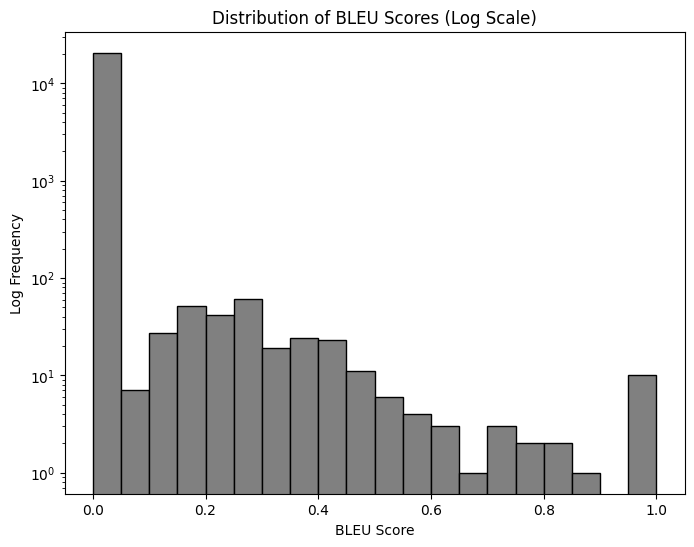

In [ ]:
import matplotlib.pyplot as plt

# Extract BLEU scores from the sample_bleu_scores list
bleu_scores = [score for _, score, _, _ in sample_bleu_scores]

plt.figure(figsize=(8, 6))
plt.hist(bleu_scores, bins=20, edgecolor='black', log=True, color='grey')
plt.xlabel('BLEU Score')
plt.ylabel('Log Frequency')
plt.title('Distribution of BLEU Scores (Log Scale)')
plt.show()

